## Business Problem Statement

A retail company operates both online and offline stores and sells multiple product categories. Management wants to better understand sales performance, customer purchasing behavior, and the effectiveness of discounts. However, they lack clear insights into which categories generate the most revenue, how customer spending varies across channels, and whether discounts actually improve sales performance.

The objective of this analysis is to identify key revenue drivers, evaluate discount impact, analyze customer behavior, and provide data-driven recommendations to improve sales strategy and operational decision-making.

## Import all libararies and packages

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 

In [2]:
df=pd.read_csv(r"C:\Users\user\Music\Retail-Sales-Analysis\data\cleaned_retail_sales.csv")

In [3]:
df.head()

,Transaction ID,Customer ID,Category,Item,Price Per Unit,Quantity,Total Spent,Payment Method,Location,Transaction Date,Discount Applied
0,TXN_6867343,CUST_09,Patisserie,Item_10_PAT,18.5,10.0,185.0,Digital Wallet,Online,2024-04-08,NaN
1,TXN_3731986,CUST_22,Milk Products,Item_17_MILK,29.0,9.0,261.0,Digital Wallet,Online,2023-07-23,NaN
2,TXN_9303719,CUST_02,Butchers,Item_12_BUT,21.5,2.0,43.0,Credit Card,Online,2022-10-05,NaN
3,TXN_9458126,CUST_06,Beverages,Item_16_BEV,27.5,9.0,247.5,Credit Card,Online,2022-05-07,NO
4,TXN_4575373,CUST_05,Food,Item_6_FOOD,12.5,7.0,87.5,Digital Wallet,Online,2022-10-02,NaN


In [4]:
df.shape

(12575, 11)

In [5]:
df.columns


Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Price Per Unit',
       'Quantity', 'Total Spent', 'Payment Method', 'Location',
       'Transaction Date', 'Discount Applied'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12575 entries, 0 to 12574
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Transaction ID    12575 non-null  object 
 1   Customer ID       12575 non-null  object 
 2   Category          12575 non-null  object 
 3   Item              12575 non-null  object 
 4   Price Per Unit    12575 non-null  float64
 5   Quantity          12575 non-null  float64
 6   Total Spent       12575 non-null  float64
 7   Payment Method    12575 non-null  object 
 8   Location          12575 non-null  object 
 9   Transaction Date  12575 non-null  object 
 10  Discount Applied  4199 non-null   object 
dtypes: float64(3), object(8)
memory usage: 1.1+ MB


## handel missing and dupplicate values

In [7]:
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    8376
dtype: int64

### percentage of missing value

In [8]:
percentage_missingValues=(df.isna().sum()/len(df))*100
percentage_missingValues

Transaction ID       0.00000
Customer ID          0.00000
Category             0.00000
Item                 0.00000
Price Per Unit       0.00000
Quantity             0.00000
Total Spent          0.00000
Payment Method       0.00000
Location             0.00000
Transaction Date     0.00000
Discount Applied    66.60835
dtype: float64

In [9]:

percentage_missingValues.sort_values(ascending=False)

Discount Applied    66.60835
Transaction ID       0.00000
Customer ID          0.00000
Category             0.00000
Item                 0.00000
Price Per Unit       0.00000
Quantity             0.00000
Total Spent          0.00000
Payment Method       0.00000
Location             0.00000
Transaction Date     0.00000
dtype: float64

In [10]:
num_columns=df.select_dtypes(include=["int64","float64"]).columns

### fill out numerical values with median 

In [11]:
df[num_columns]=df[num_columns].fillna(df[num_columns].median())

In [12]:
df.isna().sum()

Transaction ID         0
Customer ID            0
Category               0
Item                   0
Price Per Unit         0
Quantity               0
Total Spent            0
Payment Method         0
Location               0
Transaction Date       0
Discount Applied    8376
dtype: int64

### handel catogrical columns

In [13]:
df["Item"]=df["Item"].fillna("unknown")

In [14]:
df["Discount Applied"].unique()

array([nan, 'NO'], dtype=object)

In [15]:
df["Discount Applied"] = df["Discount Applied"].fillna("Unknown")

In [17]:
df["Discount Applied"].unique()

array(['Unknown', 'NO'], dtype=object)

In [16]:
df.isna().sum()

Transaction ID      0
Customer ID         0
Category            0
Item                0
Price Per Unit      0
Quantity            0
Total Spent         0
Payment Method      0
Location            0
Transaction Date    0
Discount Applied    0
dtype: int64

###  check duplicate values

In [21]:
df.duplicated().sum()

0

### change " Transaction Date " date type from object to date time

In [22]:
df["Transaction Date"]=pd.to_datetime(df["Transaction Date"],errors='coerce')

In [23]:
df["Transaction Date"].dtype

dtype('<M8[ns]')

### check consistency of values

#### this for categorical columns 

In [24]:
cat_columns=df.select_dtypes(include="object").columns

In [25]:
cat_columns

Index(['Transaction ID', 'Customer ID', 'Category', 'Item', 'Payment Method',
       'Location', 'Discount Applied'],
      dtype='object')

In [26]:
for  col in cat_columns :
    print(f"\n{col}")
    print( df[col].value_counts())


Transaction ID
Transaction ID
TXN_6867343    1
TXN_8571416    1
TXN_1906467    1
TXN_7112844    1
TXN_2571191    1
              ..
TXN_7365869    1
TXN_8331386    1
TXN_4533445    1
TXN_1796772    1
TXN_2407494    1
Name: count, Length: 12575, dtype: int64

Customer ID
Customer ID
CUST_05    544
CUST_24    543
CUST_13    534
CUST_08    533
CUST_09    519
CUST_15    519
CUST_16    515
CUST_23    513
CUST_20    507
CUST_18    507
CUST_01    507
CUST_11    503
CUST_22    501
CUST_10    501
CUST_21    498
CUST_12    498
CUST_07    491
CUST_02    488
CUST_17    487
CUST_19    487
CUST_14    484
CUST_06    481
CUST_25    476
CUST_04    474
CUST_03    465
Name: count, dtype: int64

Category
Category
Furniture                             1591
Electric household essentials         1591
Food                                  1588
Milk Products                         1584
Butchers                              1568
Beverages                             1567
Computers and electric accessories    

#### Remove extra spaces

In [27]:
df[cat_columns]=df[cat_columns].apply(lambda x :x.str.strip())

#### Check for invalid or impossible values

In [28]:
df[['Quantity', 'Price Per Unit', 'Total Spent']].describe()

,Quantity,Price Per Unit,Total Spent
count,12575.000000,12575.000000,12575.000000
mean,5.558648,23.348191,128.636581
std,2.790160,10.480413,92.557580
min,1.000000,5.000000,5.000000
25%,3.000000,14.000000,55.000000
50%,6.000000,23.000000,108.500000
75%,8.000000,32.000000,184.000000
max,10.000000,41.000000,410.000000


## Exploratry Data analysis (EDA)

### Distribution of Total Spent

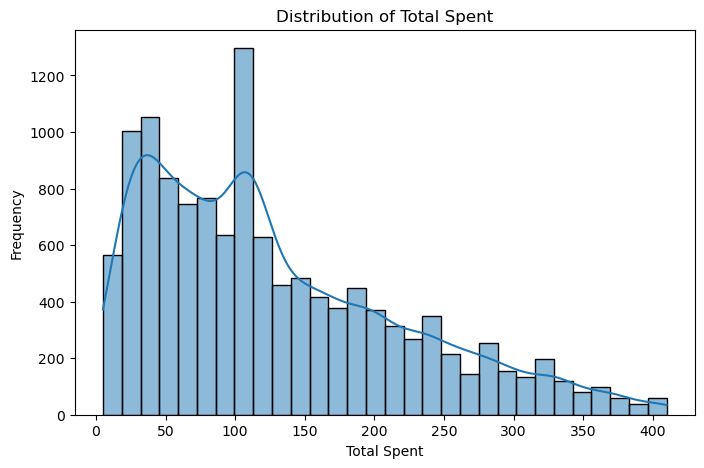

In [18]:
plt.figure(figsize=(8,5))
sns.histplot(df['Total Spent'], bins=30, kde=True)
plt.title('Distribution of Total Spent')
plt.xlabel('Total Spent')
plt.ylabel('Frequency')
plt.show()

### Sales by Category

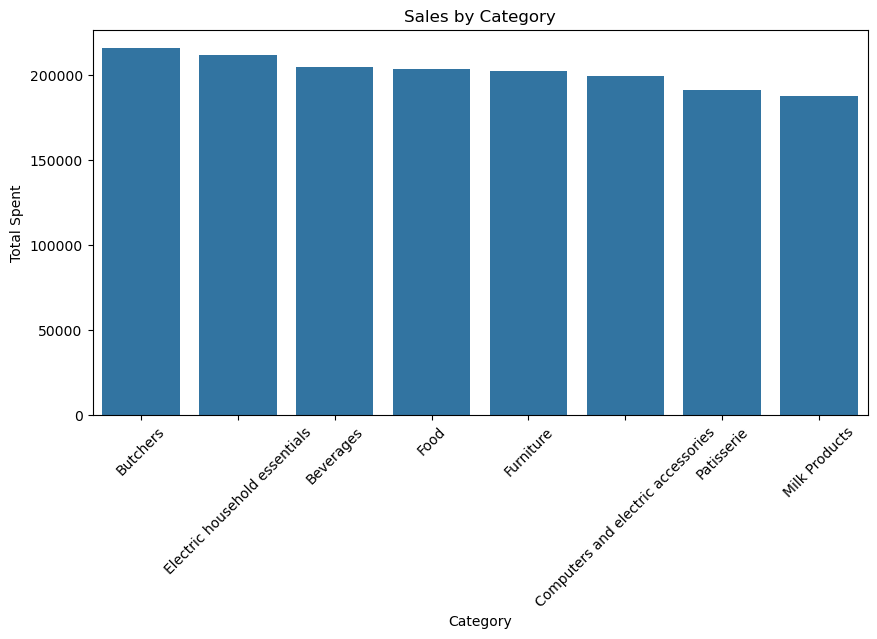

In [19]:
category_sales = (
    df.groupby('Category')['Total Spent']
    .sum()
    .reset_index()
    .sort_values(by='Total Spent', ascending=False)
)

plt.figure(figsize=(10,5))
sns.barplot(data=category_sales, x='Category', y='Total Spent')
plt.title('Sales by Category')
plt.xticks(rotation=45)
plt.show()

### Quantity vs Revenue

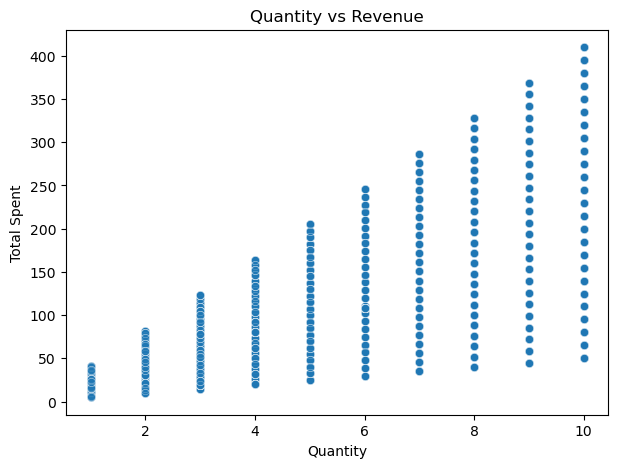

In [20]:
plt.figure(figsize=(7,5))
sns.scatterplot(
    data=df,
    x='Quantity',
    y='Total Spent',
    alpha=0.6
)
plt.title('Quantity vs Revenue')
plt.show()

### Discount vs Non-Discount Comparison

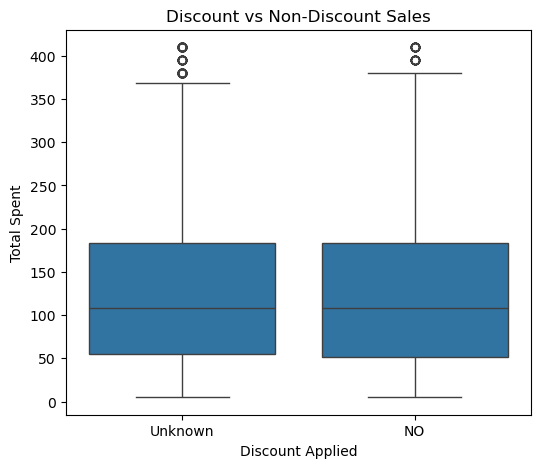

In [21]:
plt.figure(figsize=(6,5))
sns.boxplot(
    data=df,
    x='Discount Applied',
    y='Total Spent'
)
plt.title('Discount vs Non-Discount Sales')
plt.show()

### Online vs Offline Sales

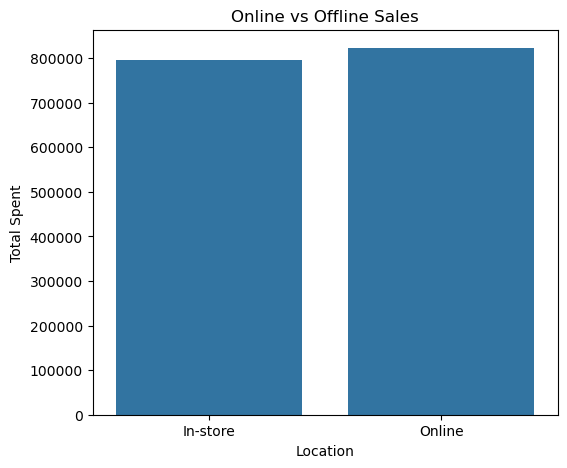

In [22]:
channel_sales = (
    df.groupby('Location')['Total Spent']
    .sum()
    .reset_index()
)

plt.figure(figsize=(6,5))
sns.barplot(data=channel_sales, x='Location', y='Total Spent')
plt.title('Online vs Offline Sales')
plt.show()

In [23]:
df.to_csv(r"C:\Users\user\Music\Retail-Sales-Analysis\data\cleaned_retail_sales.csv", index=False)